
# $$ \textbf{Lista $2a$ - Sinais e Sistemas Dinâmicos 2023.1}$$

<div>
<img src="attachment:logoCI.jpeg" width="80">
</div>

In [1]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

Esta lista aborda o tema *Análise de sinais no tempo contínuo - a série de Fourier*, onde vamos abordar três formas distintas da série:

 - **Forma Trigonométrica** 
$$
f(t)=a_0+\sum_{n=1}^{\infty} a_n \cos( n \omega_0 t) +b_n \operatorname{sen}(n \omega_0 t);
$$
 
 - **Forma Trigonométrica compacta**
 $$
f(t)=C_0+\sum_{n=1}^{\infty} C_n \cos \left(n \omega_0 t+\theta_n\right);
$$
 onde $C_n$ formam o **espectro de amplitude** e $\theta_n$ formam os **espectros de fase** do sinal.
 - **Forma Exponencial**
 $$
f(t)=\sum_{n=-\infty}^{\infty} D_n e^{j n \omega_0 t}
$$

onde a frequência $\omega_0 = \frac{2 \pi}{T_0}$ é chamada de **frequência fundamental.**

### Questão 1.

Considere o sinal $x(t)$ definido por

$$
x(t) = \begin{cases}
e^{-t/2}, \quad 0 \leq t < \pi \\
\text{sinal periódico de período $\pi$}.
\end{cases}
$$


Determine as séries de Fourier em suas formas:

- a. Trigonométrica;

como sabemos:

$$
\begin{gathered}
\omega_0=2 \pi f_0=\frac{2 \pi}{T_0} \\
a_0=\frac{1}{T_0} \int_{T_0} x(t) d t \\
a_n=\frac{2}{T_0} \int_{T_0} x(t) \cos n \omega_0 t d t \\
b_n=\frac{2}{T_0} \int_{T_0} x(t) \operatorname{sen} n \omega_0 t d t
\end{gathered}
$$

como vemos na definição do sinal, seu período é $T_0 = \pi$ e consequentemente $\omega_0 = \frac{2\pi}{pi} = 2$

$$\therefore a_0 = \frac{1}{\pi} \cdot \int_{0}^{\pi} e^{\frac{-t}{2}}dt$$
$$\frac{2}{\pi} \cdot \left( 1 - e^\frac{-\pi}{2}\right) \approx 0.504$$

In [2]:
t = sym.Symbol('t')
(1/math.pi * integrate(exp(-t/2), (t, 0, math.pi)))

0.504279523791290

para $a_n$, temos:

$$ a_n = \frac{2}{\pi} \cdot \int_{0}^{\pi} e^\frac{-t}{2} \cos{n \omega_0 t} dt $$
$$ = \frac{2}{\pi} \left[ -2e^\frac{-t}{2} \cos{n \omega_0 t} |_{0}^{\pi} - 2n\omega_0 \cdot \int_{0}^{\pi} e^\frac{-t}{2} \sin{n \omega_0 t} dt\right] $$
$$ = \frac{2}{\pi} \left[ -2e^\frac{-t}{2} \cos{n \omega_0 t} |_{0}^{\pi} - 2n\omega_0 \cdot \left[ e^\frac{-t}{2} \sin{n \omega_0 t} |_{0}^{\pi} - 2n\omega_0 \cdot \int_{0}^{\pi} e^\frac{-t}{2} \cos{n \omega_0 t} dt \right] \right] $$

tomando os limites temos:

$$ \frac{-4e^\frac{-\pi}{2} \cos{n \omega_0 \pi}}{\pi} + \frac{4}{\pi} - \frac{-8e^\frac{-\pi}{2}n^2\omega_0^2 \sin{n \omega_0 \pi}}{\pi} \cdot \int_{0}^{\pi} e^\frac{-t}{2} \cos{n \omega_0 t} dt$$

passando o fator $\int_{0}^{\pi} e^\frac{-t}{2} \cos{n \omega_0 t} dt$ para o outroo lado e dividindo pelo coeficiente temos como resultado:

$$ 4e^\frac{-\pi}{2} \cdot \left[ \frac{4n\sin( n2 \pi) - cos(n2\pi) + e^\frac{\pi}{2}}{16\pi n^2 + \pi}\right]$$

que pode ser reescrita como: 

$$ a_n = \frac{-4e^\frac{-\pi}{2} + 4}{16\pi n^2 + \pi}$$

In [3]:
n = sym.Symbol('n')
(2/math.pi * integrate(exp(-t/2) * cos(2*n*t), (t, 0, math.pi)))

5.09295817894065*n*sin(6.28318530717959*n)/(76.9676380954456*n**2 + 4.81047738096535) - 1.27323954473516*cos(6.28318530717959*n)/(76.9676380954456*n**2 + 4.81047738096535) + 1.27323954473516/(16*n**2 + 1)

de maneira bastante similar para $b_n$, obtemos:

$$b_n = \frac{16n-16ne^\frac{-\pi}{2}}{16\pi n^2 + \pi}$$

In [4]:
(2/math.pi * integrate(exp(-t/2) * sin(2*n*t), (t, 0, math.pi)))

-5.09295817894065*n*cos(6.28318530717959*n)/(76.9676380954456*n**2 + 4.81047738096535) + 5.09295817894065*n/(16*n**2 + 1) - 1.27323954473516*sin(6.28318530717959*n)/(76.9676380954456*n**2 + 4.81047738096535)

portanto, a representação trigonométrica do sinal é:

$$g(t) = \frac{-2}{\pi} \cdot \left( e^\frac{-\pi}{2} - 1\right) + \sum_{n=1}^{\infty} \frac{-4e^\frac{-\pi}{2} + 4}{16\pi n^2 + \pi} \cos(n2t) + \frac{16n-16ne^\frac{-\pi}{2}}{16\pi n^2 + \pi} \sin(n2t) $$

- b. Trigonométrica compacta;

para converter da forma trigonométrica para a forma compacta é possível utilizar essas relações:
 
$$
\begin{aligned}
& C_0=a_0 \\
& C_n=\sqrt{a_n^2+b_n^2} \\
& \theta_n=\tan ^{-1}\left(\frac{-b_n}{a_n}\right)
\end{aligned}
$$

$$\therefore C_n = \sqrt{\frac{\left( -4e^\frac{-\pi}{2} + 4\right)^2 + \left( 16n - 16ne^\frac{-\pi}{2}\right)^2}{\left(16\pi n^2 + \pi\right)^2}}$$
$$ \therefore C_n = \sqrt{\left(\frac{- e^\frac{-\pi}{2} + 1}{\pi}\right)^2 \cdot \left(\frac{4+16n}{16e*2 + 1}\right)^2}$$
$$\therefore C_n = \frac{- e^\frac{-\pi}{2} + 1}{\pi} \sqrt{\frac{16+256n^2}{\left(16n^2+1\right)^2}} $$

In [25]:
(16+256*n**2)/((16*n+1)**2).simplify()

(256*n**2 + 16)/(16*n + 1)**2

In [11]:
sqrt((.504 * (2/(1 + 16*n**2)))**2 + (.504 * ((8*n)/(1+16*n**2)))**2)

4.032*sqrt(n**2/(16*n**2 + 1)**2 + 0.0625/(16*n**2 + 1)**2)

In [5]:
sqrt(((-4*exp(pi/2) + 4 + 16*n + 16*n*exp(pi/2))**2)/(16*pi*n*n+pi)**2).simplify()

4*sqrt((4*n + 4*n*exp(pi/2) - exp(pi/2) + 1)**2/(16*n**2 + 1)**2)/pi

e

$$ \theta_n = \tan ^{-1}\left(\frac{-b_n}{a_n}\right) $$
$$ \theta_n = \tan ^{-1}\left(\frac{-\frac{16n-16ne^\frac{-\pi}{2}}{16\pi n^2 + \pi}}{\frac{-4e^\frac{-\pi}{2} + 4}{16\pi n^2 + \pi}}\right) $$
$$ \theta_n = \tan ^{-1}\left(\frac{-16n-16ne^\frac{-\pi}{2}}{-4e^\frac{-\pi}{2} + 4}\right) $$
$$ \theta_n = \tan ^{-1}\left(\frac{4n+4ne^\frac{-\pi}{2}}{e^\frac{-\pi}{2} - 1}\right) $$
$$ \theta_n = \tan ^{-1}\left(-4n \cdot \frac{ne^\frac{-\pi}{2} - 1}{e^\frac{-\pi}{2} - 1}\right)$$
$$ \theta_n = \tan ^{-1}\left(-4n\right)$$

Portanto, a série trigonométrica na sua forma compacta do sinal é igual à: 
$$g(t) = C_0+\sum_{n=1}^{\infty} C_n \cos \left(n \omega_0 t+\theta_n\right)$$
$$g(t) = \frac{-2}{\pi} \cdot \left( e^\frac{-\pi}{2} - 1\right) + \frac{- e^\frac{-\pi}{2} + 1}{\pi} \cdot \sum_{n=1}^{\infty}  \sqrt{\frac{16+256n^2}{\left(16n^2+1\right)^2}} \cdot \cos \left(n 2 t + \tan ^{-1}\left(-4n\right) \right)$$

- c. Exponencial.

utilizando a fórmula de cálculo de coeficientes, temos:

$$ \frac{1}{\pi} \cdot \int_0^\pi e^\frac{-t}{2} e^{-j2 n t} dt$$
$$ \frac{1}{\pi} \cdot \int_0^\pi e^{- \left(j2 n t + \frac{t}{2} \right)} dt$$
$$ \frac{1}{\pi} \cdot \left( - \frac{e^{- \left(j2 n t + \frac{t}{2} \right)}}{j2n + \frac{1}{2}}\right) \biggr|_0^\pi$$
$$ \frac{1}{\pi} \cdot \left( - \frac{e^{- \left(j2\pi n  + \frac{\pi}{2} \right)}}{j2n + \frac{1}{2}} + \frac{1}{j2n + \frac{1}{2}}\right)$$
$$ \frac{1}{\pi} \cdot \frac{2-2e^{- \left(j2\pi n  + \frac{\pi}{2} \right)}}{j4n+1}$$
$$\therefore a_n = \frac{2}{\pi} \cdot \frac{1-e^{- \left(j2\pi n  + \frac{\pi}{2} \right)}}{j4n+1}$$

portanto, sua representação exponencial é dada por:

$$ g(t) = \frac{2}{\pi} \cdot \sum_{n=0}^\infty \frac{1-e^{- \left(j2\pi n  + \frac{\pi}{2} \right)}}{j4n+1} \cdot e^{-j2nt}$$
$$ g(t) = \frac{2}{\pi} \cdot \sum_{n=0}^\infty \frac{e^{-j2nt} - e^{- \left(j2\pi n  + \frac{\pi}{2} + j2nt\right)}}{j4n+1}$$

- d. Esboce o gráfico do sinal $x(t)$ e trace seus espectros de fase e amplitude.

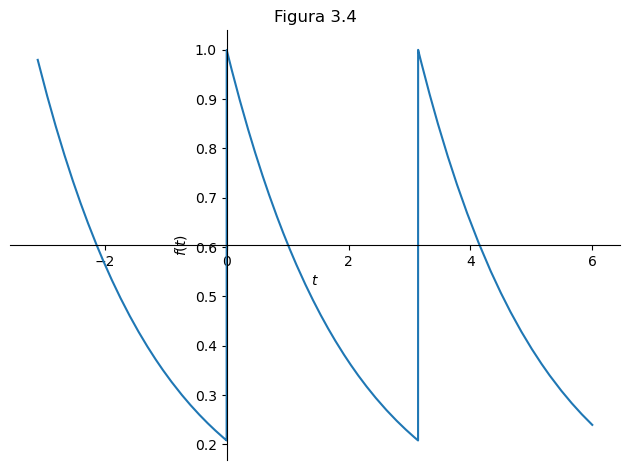

In [6]:
g = sym.Piecewise((exp(-(t+pi)/2), (-pi <= t) & (t < 0)),
                    ((exp(-t/2), (0 <= t) & (t < pi))),
                    ((exp(-(t-pi)/2), (pi <= t) & (t < 2*pi))), (0, True))
p1 = sym.plot(g, (t, -3.1, 6), title='Figura 3.4', show=True)

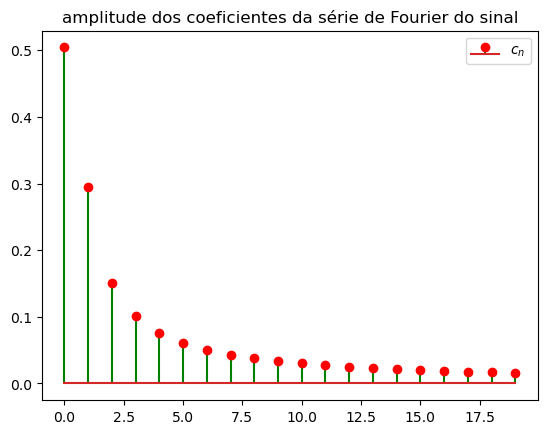

In [26]:
z = [0]
z1 = [2/math.pi * (1 - exp(-math.pi/2))]
for k in range(1, 20):
    z.append(k)
    z1.append(((-exp(-math.pi) + 1)/math.pi) * sqrt((16+256*k**2)/((16*k**2+1)**2)))

plt.stem(z, z1, 'g', markerfmt='ro', label='$c_n$')
plt.legend()
plt.title('amplitude dos coeficientes da série de Fourier do sinal')
plt.show()

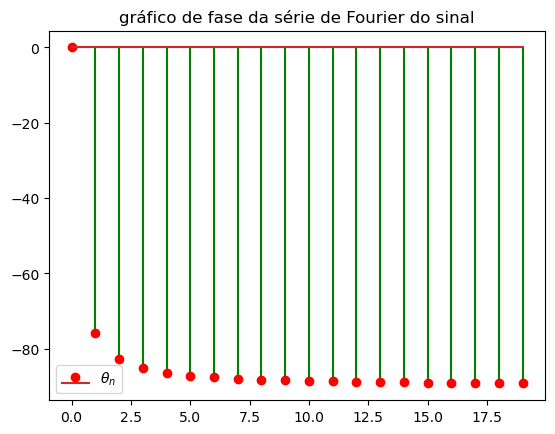

In [51]:
z = [0]
z1 = [0]
for k in range(1, 20):
    z.append(k)
    z1.append(math.degrees(math.atan(-4*k)))

plt.stem(z, z1, 'g', markerfmt='ro', label='$\\theta_n$')
plt.legend()
plt.title('gráfico de fase da série de Fourier do sinal')
plt.show()

### Questão 2.

Repita a questão 1 para o sinal periódico $x(t)$ definido por

$$
x(t) = \begin{cases}
2At, \quad -0.5 \leq t < 0.5 \\
\text{sinal periódico de período $T_0 = 1$},
\end{cases}
$$
onde $A$ é um número real positivo.

dado que $\omega_0 = \frac{2\pi}{1} = 2\pi$:

$$a_0 = \frac{1}{1} \cdot 2A \cdot \int_{-0.5}^{0.5} t dt = 2A \cdot \left( \frac{1}{4} - \frac{1}{4}\right) = 0$$

para $a_n$:

$$a_n = 4A \cdot \int_{-0.5}^{0.5} t\cos(n2\pi t) dt$$
fazendo $u = n2\pi t$:
$$a_n = \frac{4A}{n2\pi} \cdot \left[ (t \sin(u))\biggr|_{-n\pi}^{n\pi} - \int_{-0.5}^{0.5} \sin(n2\pi t) dt \right]$$
$$a_n = \frac{4A}{n2\pi} \cdot \left[ 0 - \frac{1}{n2\pi} (\cos(n\pi) - \cos(n\pi))\right]$$
$$a_n = 0$$

e para $b_n$:
$$ b_n = 4A \cdot \int_{-0.5}^{0.5} t\sin(n2\pi t) dt$$
$$ b_n = \frac{4A}{2n\pi} \cdot \left[ -t \cos(2n\pi t) \biggr|_{-\frac{1}{2}}^{\frac{1}{2}} + \frac{1}{n2\pi}\int_{-0/5}^{0.5}\cos(2n\pi t) dt\right]$$
$$ b_n = \frac{2A}{n\pi} \cdot \left[\cos(n\pi) + \frac{1}{n2\pi} \cdot \left( \sin(n\pi) - \sin(n\pi) \right)\right]$$
$$\therefore b_n = \frac{2A \cdot \cos(n\pi)}{n\pi}$$

logo, o sinal tem como representação trigonométrica:

$$g(t) = \sum_{n=0}^\infty \frac{2A \cdot \cos(n\pi)}{n\pi} \sin(n2\pi t)$$

- b. Trigonométrica compacta;

como sabemos, podemos transformar uma função seno em uma função cosseno atrasando 90 graus de fase, portanto:

$$g(t) = \sum_{n=0}^\infty \frac{2A \cdot \cos(n\pi)}{n\pi} \cos(n2\pi t - 90^{\circ})$$

ou, analizando algebricamente, temos que $C_n = \sqrt{b_n^2} = b_n$ e $\theta_n = -\infty = -90$

- c. Exponencial.

para achar a forma exponencial temos:

$$D_n = \frac{1}{1} \cdot 2A \cdot \int_{-0.5}^{0.5} te^{-jn2\pi t} dt$$
$$ 2A \cdot \left[ \frac{-te^{-jn2\pi t}}{jn2\pi} \biggr|_{-\frac{1}{2}}^{\frac{1}{2}} + \frac{1}{jn2\pi} \int_{-0.5}^{0.5} e^{jn2\pi t} dt\right]$$
$$ 2A \cdot \left[ \frac{1}{2} \left(\frac{-e^{-jn\pi}}{jn2\pi} + \frac{-e^{jn\pi}}{jn2\pi}\right) + \frac{1}{jn2\pi} \left( e^{-jn\pi} - e^{jn\pi}\right)\right]$$
$$ \frac{2A}{jn2\pi} \cdot \left[ \frac{1}{2} \left(-e^{-jn\pi} + -e^{jn\pi}\right) + \left( e^{-jn\pi} - e^{jn\pi}\right)\right]$$
$$ \frac{2A}{jn2\pi} \cdot \left[ \frac{1}{2} \left( e^{-jn\pi} - e^{jn\pi}\right)\right]$$
$$ \frac{2A}{jn4\pi} \cdot \left( e^{-jn\pi} - e^{jn\pi}\right)$$

portanto, a fórma exponencial é dada por:

$$ g(t) = \sum_{n=0}^{\infty} \frac{2A}{jn4\pi} \cdot \left( e^{-jn\pi} - e^{jn\pi}\right) \cdot e^{-jn2\pi t}$$

- d. Esboce o gráfico do sinal $x(t)$ e trace seus espectros de fase e amplitude.

para A = 1, temos:

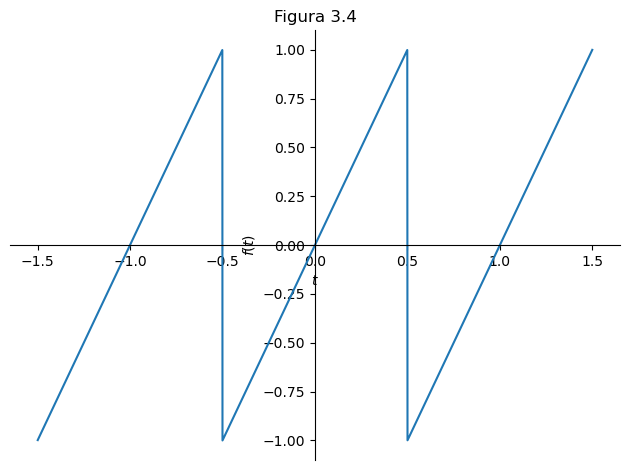

In [45]:
g = sym.Piecewise((2*t, (-0.5 <= t) & (t <=0.5)),
                  (2*(t - 1), (0.5 <= t) & (t <=1.5)), 
                  (2*(t + 1), (-1.5 <= t) & (t <=-0.5)))


p1 = sym.plot(g, (t, -3.1, 6), title='Figura 3.4', show=True)

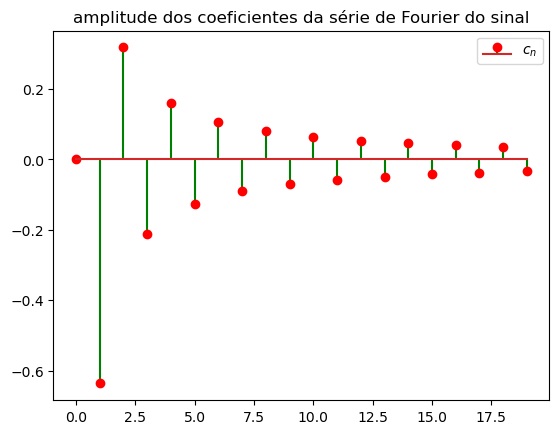

In [46]:
z = [0]
z1 = [0]
for k in range(1, 20):
    z.append(k)
    z1.append(2*math.cos(k*math.pi)/(k*math.pi))

plt.stem(z, z1, 'g', markerfmt='ro', label='$c_n$')
plt.legend()
plt.title('amplitude dos coeficientes da série de Fourier do sinal')
plt.show()

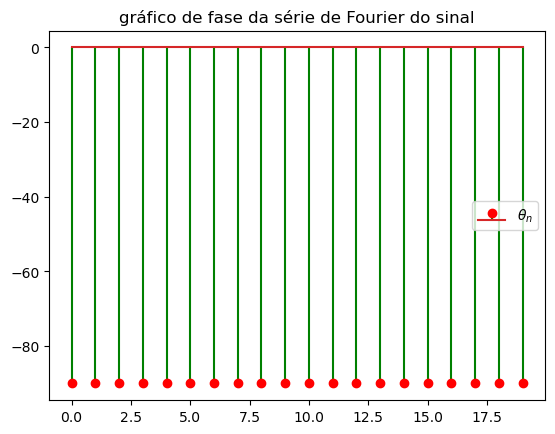

In [50]:
z = [a for a in range (0, 20)]
z1 = [-90 for a in range (0, 20)]

plt.stem(z, z1, 'g', markerfmt='ro', label='$\\theta_n$')
plt.legend()
plt.title('gráfico de fase da série de Fourier do sinal')
plt.show()

### Questão 3.

Um sinal periódico $x(t)$ é representado por uma série trigonométrica de Fourier como
$$
x(t)=2+3 \cos 2 t+4 \operatorname{sen} 2 t+2 \operatorname{sen}\left(3 t+30^{\circ}\right)-\cos \left(7 t+150^{\circ}\right)
$$
Expresse essa série como uma série trigonométrica compacta de Fourier e trace o espectro de amplitude e fase de $x(t)$.

como sabemos, a função seno pode ser representada por: $\sin(x) = \cos(x+90^{\circ})$, e como $3 \cos{2t}$ e $4sen{2t}$ têm a mesma frequência, podemos utilizar as fórmulas $\sqrt{a^2 + b^2}$ e $arctg\left({\frac{b}{a}}\right)$


portanto: $\sin{3t+30^{\circ}} = \cos{(3t - 60^{\circ})}$   
e $\cos{2t} + 4sen{2t}$ = $5\cos{(2t-53.13^{\circ})}$

$$\therefore g(t) = 2 +5\cos(2t-53.13^{\circ}) + 2 cos(3t - 60^{\circ}) + cos(7t+150^{\circ})$$

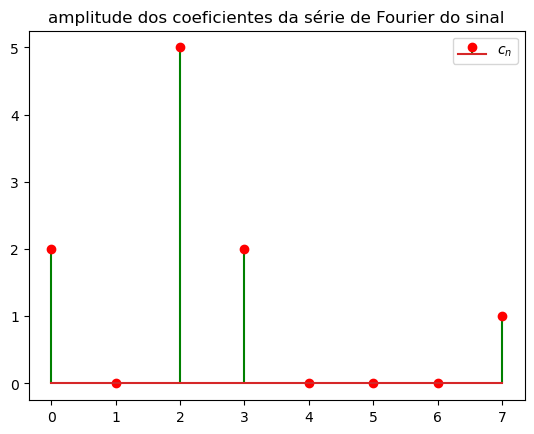

In [33]:
z = [a for a in range(0, 8)]
z1 = [2, 0, 5, 2, 0, 0, 0, 1]

plt.stem(z, z1, 'g', markerfmt='ro', label='$c_n$')
plt.legend()
plt.title('amplitude dos coeficientes da série de Fourier do sinal')
plt.show()

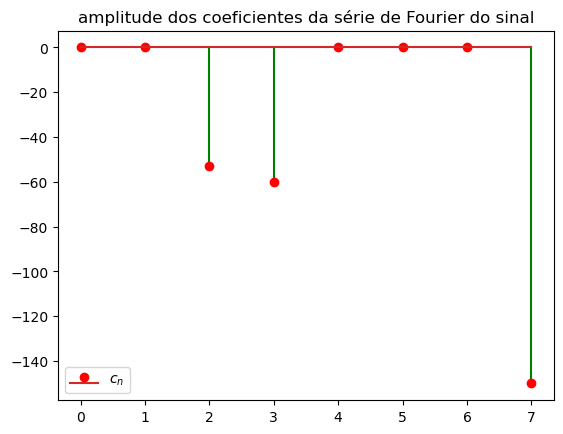

In [34]:
z = [a for a in range(0, 8)]
z1 = [0, 0, -math.degrees(math.atan(4/3)), -60, 0, 0, 0, -150]

plt.stem(z, z1, 'g', markerfmt='ro', label='$c_n$')
plt.legend()
plt.title('gráfico de fase da série de Fourier do sinal')
plt.show()